# STG3Net RCC_TLS_10x Subject 22 Benchmark

This notebook runs **STG3Net** on the `RCC_TLS_10x` dataset using **Subject 22 only**.

Training unit:
- `subject_22`: `GSM5924030_ffpe_c_2`, `GSM5924050_frozen_c_2`

Benchmark setting:
- Fixed cluster number: `3`
- Output style follows the SpaCross / DLPFC benchmark:
  - `performance.parquet`
  - `predictions.parquet`
  - `benchmark.log`

Because STG3Net is a multi-slice / multi-sample integration method, this notebook trains once on the two Subject 22 samples and then reports metrics separately for each sample.


# Imports and environment setup

In [1]:
# =============================================================================
# Imports and environment setup
# =============================================================================
import os
import sys
import time
import logging
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

# Make the kernel robust if launched through VSCode/Jupyter rather than
# from an already activated conda shell.
CONDA_PREFIX = Path(sys.executable).resolve().parents[1]

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["DGLBACKEND"] = "pytorch"

# Force Linux conda R, not the author's Windows R path.
os.environ["R_HOME"] = str(CONDA_PREFIX / "lib" / "R")
os.environ.pop("R_USER", None)

# Make conda libraries preferred inside Jupyter.
os.environ["LD_LIBRARY_PATH"] = (
    f"{CONDA_PREFIX}/lib:"
    f"{CONDA_PREFIX}/lib/python3.10/site-packages/nvidia/cuda_nvrtc/lib:"
    + os.environ.get("LD_LIBRARY_PATH", "")
)

print("Python:", sys.executable)
print("CONDA_PREFIX:", CONDA_PREFIX)
print("R_HOME:", os.environ["R_HOME"])
print("R_USER:", os.environ.get("R_USER"))

import numpy as np
import pandas as pd
import scanpy as sc
import torch
import yaml
from sklearn.decomposition import PCA
from sklearn import metrics as sk_metrics

import dgl
import torch_geometric
import torch_scatter
import torch_sparse
import torch_cluster

print("torch:", torch.__version__, "cuda:", torch.cuda.is_available(), "torch cuda:", torch.version.cuda)
print("dgl:", dgl.__version__)
print("pyg:", torch_geometric.__version__)
print("scanpy:", sc.__version__)


Python: /work/dal875013/conda_envs/stg3net_env/bin/python
CONDA_PREFIX: /work/dal875013/conda_envs/stg3net_env
R_HOME: /work/dal875013/conda_envs/stg3net_env/lib/R
R_USER: None
torch: 2.2.2+cu118 cuda: True torch cuda: 11.8
dgl: 2.2.1+cu118
pyg: 2.5.2
scanpy: 1.10.1


# User configuration and general helpers

In [ ]:
# =============================================================================
# USER CONFIGURATION
# =============================================================================

# Path to cloned STG3Net repo
STG3NET_ROOT = Path(r"/work/dal875013/projects/mocha/methods/STG3Net")

# Path to RCC_TLS_10x .h5ad files.
# Expected filenames are usually SCE_<sample_id>.h5ad, but the loader below
# also searches for any .h5ad file containing the sample_id.
DATA_ROOT = Path(r"/groups/qiwei/mocha/QuickSRT/RCC_TLS_10x/data")

# Output folder for parquet results
OUTPUT_DIR = Path(r"/work/dal875013/projects/mocha/results/STG3Net/rcc_tls_stg3net")

# STG3Net config. Reuse the author's DLPFC config unless you create a
# dataset-specific RCC config later.
CONFIG_PATH = STG3NET_ROOT / "Config" / "Config_DLPFC.yaml"

# RCC_TLS Subject 22 has two samples.
RCC_TLS_SUBJECT_GROUPS = {
    "subject_22": ["GSM5924030_ffpe_c_2", "GSM5924050_frozen_c_2"],
}

# This notebook is intentionally restricted to Subject 22 only.
GROUPS_TO_RUN = "subject_22"

METHOD_NAME = "STG3Net"
CLUST_METHOD = "mclust"
NUM_RUNS = 1

# RCC_TLS labels are No TLS, TLS, and T-cell aggregate, so use 3 clusters.
FIXED_NUM_CLUSTERS = 3

# Ground-truth label column.
# Set to None to auto-detect. If the notebook complains, inspect adata.obs columns
# and set this manually, e.g. GT_LABEL_COL = "z" or "annotation".
GT_LABEL_COL = None

# Preprocessing. Slightly less aggressive than DLPFC because RCC_TLS samples can
# differ in spot/gene counts.
MIN_CELLS = 10
MIN_COUNTS = 10
MAX_PCS = 200


# =============================================================================
# General helpers
# =============================================================================
def setup_logging(output_dir: Path):
    output_dir.mkdir(parents=True, exist_ok=True)
    log_file = output_dir / "benchmark.log"
    logging.basicConfig(
        level=logging.INFO,
        format="%(asctime)s [%(levelname)s] %(message)s",
        handlers=[
            logging.StreamHandler(sys.stdout),
            logging.FileHandler(log_file, mode="w"),
        ],
        force=True,
    )
    logging.info(f"Log file: {log_file}")


def get_device():
    """Return 'cuda:0' if a CUDA GPU is available, else 'cpu'. Logs details."""
    if torch.cuda.is_available():
        dev = "cuda:0"
        os.environ["CUDA_VISIBLE_DEVICES"] = "0"
        logging.info(f"[DEVICE] CUDA available — using {dev}")
        logging.info(f"[DEVICE] GPU name: {torch.cuda.get_device_name(0)}")
        logging.info(
            f"[DEVICE] GPU memory: "
            f"{torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB"
        )
    else:
        dev = "cpu"
        logging.warning("[DEVICE] No CUDA GPU detected — falling back to CPU")
    return dev


def resolve_groups(selector) -> dict:
    """Turn GROUPS_TO_RUN into a concrete dict: group_name -> sample_ids."""
    if selector is None or selector == "all":
        return dict(RCC_TLS_SUBJECT_GROUPS)
    if isinstance(selector, str):
        return {selector: RCC_TLS_SUBJECT_GROUPS[selector]}
    if isinstance(selector, (list, tuple)):
        return {name: RCC_TLS_SUBJECT_GROUPS[name] for name in selector}
    raise ValueError(f"Unrecognized GROUPS_TO_RUN value: {selector!r}")


def find_h5ad_for_sample(sample_id: str) -> Path:
    """Find .h5ad file for a sample using several common naming patterns."""
    candidates = [
        DATA_ROOT / f"SCE_{sample_id}.h5ad",
        DATA_ROOT / f"{sample_id}.h5ad",
        DATA_ROOT / f"sce_{sample_id}.h5ad",
    ]
    for p in candidates:
        if p.exists():
            return p

    matches = sorted(DATA_ROOT.glob(f"*{sample_id}*.h5ad"))
    if len(matches) == 1:
        return matches[0]
    if len(matches) > 1:
        raise RuntimeError(
            f"Multiple .h5ad files matched sample_id={sample_id}: {matches}. "
            "Please make the filename rule explicit in find_h5ad_for_sample()."
        )
    raise FileNotFoundError(
        f"Could not find .h5ad for sample_id={sample_id} under {DATA_ROOT}. "
        f"Checked: {candidates} and glob '*{sample_id}*.h5ad'."
    )


def detect_gt_column(adata) -> str:
    """Auto-detect which obs column holds the ground-truth annotation label."""
    if GT_LABEL_COL is not None:
        if GT_LABEL_COL not in adata.obs.columns:
            raise KeyError(
                f"GT_LABEL_COL={GT_LABEL_COL!r} not in adata.obs. "
                f"Available columns: {list(adata.obs.columns)}"
            )
        return GT_LABEL_COL

    # Prefer common benchmark labels first.
    candidates = [
        "z", "label", "labels", "annotation", "Annotation", "manual_annotation",
        "Ground Truth", "ground_truth", "GroundTruth", "truth", "manual_label",
        "domain", "Domain", "spatial_domain", "cluster", "Cluster",
        "TLS", "tls", "TLS_label", "tls_label",
    ]
    for c in candidates:
        if c in adata.obs.columns:
            return c

    # Fallback: search for annotation-like names.
    for c in adata.obs.columns:
        lc = str(c).lower()
        if any(key in lc for key in ["annot", "label", "truth", "tls", "domain"]):
            return c

    raise KeyError(
        f"Could not auto-detect ground-truth column. "
        f"adata.obs columns: {list(adata.obs.columns)}. "
        f"Please set GT_LABEL_COL manually."
    )


def to_numpy(x):
    """Convert torch tensor / sparse / dense object to numpy array."""
    if hasattr(x, "detach"):
        return x.detach().cpu().numpy()
    if hasattr(x, "data") and hasattr(x.data, "cpu"):
        return x.data.cpu().numpy()
    if hasattr(x, "toarray"):
        return x.toarray()
    return np.asarray(x)


def get_num_clusters() -> int:
    """Return fixed number of RCC_TLS clusters."""
    return int(FIXED_NUM_CLUSTERS)


def check_mclust_if_needed():
    """Fail early if mclust clustering is requested but unavailable."""
    if CLUST_METHOD != "mclust":
        return
    try:
        import rpy2.robjects.packages as rpackages
        if not rpackages.isinstalled("mclust"):
            raise RuntimeError(
                "R package 'mclust' is not installed in stg3net_env. Run this once:\n"
                "conda install -n stg3net_env -c conda-forge r-mclust -y"
            )
    except Exception as e:
        raise RuntimeError(
            "Cannot verify R package 'mclust'. If you plan to use CLUST_METHOD='mclust', run:\n"
            "conda install -n stg3net_env -c conda-forge r-mclust -y\n"
            f"Original error: {e}"
        )


def patch_stg3net_windows_r_paths():
    """
    Patch the author's hard-coded Windows R paths in STG3Net/Utils.py.

    This is needed on Juno because STG3Net/Utils.py originally contains
    Windows R_HOME/R_USER paths. The patch is idempotent and keeps a .bak file.
    """
    utils_path = STG3NET_ROOT / "STG3Net" / "Utils.py"
    if not utils_path.exists():
        raise FileNotFoundError(f"Cannot find {utils_path}")

    text = utils_path.read_text()
    if "D:/software/R/R-4.3.2" not in text and "D:/software/anaconda" not in text:
        logging.info("[PATCH] No Windows R paths detected in STG3Net/Utils.py")
        return

    bak_path = utils_path.with_suffix(".py.bak")
    if not bak_path.exists():
        bak_path.write_text(text)

    if "import sys" not in text:
        text = text.replace("import os\n", "import os\nimport sys\n", 1)

    old = (
        "os.environ['R_HOME'] = 'D:/software/R/R-4.3.2'\n"
        "os.environ['R_USER'] = 'D:/software/anaconda/anaconda3/envs/pt20cu118/Lib/site-packages/rpy2'\n"
    )
    new = (
        "CONDA_PREFIX = os.environ.get('CONDA_PREFIX', os.path.dirname(os.path.dirname(sys.executable)))\n"
        "os.environ['R_HOME'] = os.environ.get('R_HOME', os.path.join(CONDA_PREFIX, 'lib', 'R'))\n"
        "os.environ.pop('R_USER', None)\n"
    )
    if old in text:
        text = text.replace(old, new)
    else:
        # Fallback line-by-line cleanup if whitespace changed.
        lines = []
        for line in text.splitlines():
            if "D:/software/R/R-4.3.2" in line:
                lines.append(
                    "os.environ['R_HOME'] = os.environ.get('R_HOME', os.path.join(CONDA_PREFIX, 'lib', 'R'))"
                )
            elif "D:/software/anaconda" in line:
                lines.append("os.environ.pop('R_USER', None)")
            else:
                lines.append(line)
        text = "\n".join(lines) + "\n"

    utils_path.write_text(text)

    pycache = STG3NET_ROOT / "STG3Net" / "__pycache__"
    if pycache.exists():
        import shutil
        shutil.rmtree(pycache)

    logging.info("[PATCH] Patched STG3Net/Utils.py Windows R paths")


# Subject 22 data loading

In [3]:
# =============================================================================
# Subject-level data loading
# =============================================================================
def load_one_rcc_tls_sample_for_stg3net(
    sample_id: str,
    slice_id: int,
    config_data: dict,
    model_mod,
):
    """
    Load one RCC_TLS_10x .h5ad sample and build its STG3Net graph before concatenation.
    """
    h5ad_path = find_h5ad_for_sample(sample_id)
    logging.info(f"    [LOAD] Reading {h5ad_path}")

    adata_tmp = sc.read_h5ad(h5ad_path)
    adata_tmp.var_names_make_unique()

    logging.info(
        f"    [DIAG] {sample_id}: n_obs={adata_tmp.n_obs}, n_vars={adata_tmp.n_vars}"
    )
    logging.info(f"    [DIAG] {sample_id}: obs columns={list(adata_tmp.obs.columns)}")
    logging.info(f"    [DIAG] {sample_id}: obsm keys={list(adata_tmp.obsm.keys())}")

    gt_col = detect_gt_column(adata_tmp)
    adata_tmp.obs["layer_guess"] = adata_tmp.obs[gt_col].astype(object)
    adata_tmp.obs["batch_name"] = sample_id
    adata_tmp.obs["slice_id"] = int(slice_id)
    adata_tmp.obs["proj_name"] = sample_id
    adata_tmp.obs["sample"] = sample_id
    adata_tmp.obs["original_spot_id"] = adata_tmp.obs_names.astype(str)

    n_labeled = int(adata_tmp.obs["layer_guess"].notna().sum())
    logging.info(
        f"    [DIAG] {sample_id}: using GT column '{gt_col}' "
        f"(labeled spots: {n_labeled}/{adata_tmp.n_obs})"
    )
    logging.info(
        f"    [DIAG] {sample_id}: label counts="
        f"{adata_tmp.obs['layer_guess'].astype(str).value_counts(dropna=False).to_dict()}"
    )

    if "spatial" not in adata_tmp.obsm:
        if "S" in adata_tmp.obsm:
            adata_tmp.obsm["spatial"] = np.asarray(adata_tmp.obsm["S"])
            logging.info(f"    [DIAG] {sample_id}: aliased obsm['S'] -> obsm['spatial']")
        else:
            raise KeyError(
                f"No spatial coordinates found in {h5ad_path}. "
                f"Available obsm keys: {list(adata_tmp.obsm.keys())}"
            )

    k = int(config_data["k_cutoff"])
    graph_dict_tmp = model_mod.graph_construction(adata_tmp, k)
    logging.info(f"    [DIAG] {sample_id}: built STG3Net graph_dict with k={k}")

    return adata_tmp, graph_dict_tmp, gt_col


def load_rcc_tls_subject_group(
    group_name: str,
    sample_ids: list,
    config: dict,
    model_mod,
):
    """
    Load and concatenate RCC_TLS Subject 22 samples, matching STG3Net's
    multi-sample input design.

    Returns:
        adata      : concatenated and preprocessed AnnData
        graph_dict : combined STG3Net graph dictionary
        gt_cols    : dict sample_id -> original GT column
    """
    logging.info(f"  [GROUP] Loading {group_name}: {sample_ids}")

    adata = None
    graph_dict = None
    gt_cols = {}

    for slice_idx, sample_id in enumerate(sample_ids):
        adata_tmp, graph_dict_tmp, gt_col = load_one_rcc_tls_sample_for_stg3net(
            sample_id=sample_id,
            slice_id=slice_idx,
            config_data=config["data"],
            model_mod=model_mod,
        )
        gt_cols[sample_id] = gt_col

        if adata is None:
            adata = adata_tmp
            graph_dict = graph_dict_tmp
        else:
            # Match the author's multi-slice logic: intersect genes before concatenation.
            var_names = adata.var_names.intersection(adata_tmp.var_names)
            adata = adata[:, var_names].copy()
            adata_tmp = adata_tmp[:, var_names].copy()

            adata = adata.concatenate(adata_tmp)
            graph_dict = model_mod.combine_graph_dict(graph_dict, graph_dict_tmp)

    logging.info(
        f"  [DIAG] Combined {group_name}: n_obs={adata.n_obs}, n_vars={adata.n_vars}, "
        f"batches={adata.obs['batch_name'].astype(str).unique().tolist()}"
    )

    # Preprocessing after concatenation.
    sc.pp.filter_genes(adata, min_cells=MIN_CELLS)
    sc.pp.filter_genes(adata, min_counts=MIN_COUNTS)
    logging.info(f"  [DIAG] {group_name}: after gene filtering n_vars={adata.n_vars}")

    # Store raw counts for Seurat v3 HVG before normalization.
    adata.layers["count"] = adata.X.copy()

    sc.pp.normalize_total(adata, target_sum=1e6)

    n_top_genes = int(min(config["data"]["top_genes"], adata.n_vars))
    sc.pp.highly_variable_genes(
        adata,
        flavor="seurat_v3",
        layer="count",
        n_top_genes=n_top_genes,
    )
    adata = adata[:, adata.var["highly_variable"]].copy()
    sc.pp.scale(adata)

    logging.info(
        f"  [DIAG] {group_name}: after HVG selection n_vars={adata.n_vars} "
        f"(target top_genes={n_top_genes})"
    )

    n_pcs = max(1, min(MAX_PCS, adata.n_vars, adata.n_obs - 1))
    X_for_pca = adata.X.toarray() if hasattr(adata.X, "toarray") else np.asarray(adata.X)
    adata.obsm["X_pca"] = PCA(n_components=n_pcs, random_state=42).fit_transform(X_for_pca)
    logging.info(f"  [DIAG] {group_name}: PCA done, X_pca shape={adata.obsm['X_pca'].shape}")

    return adata, graph_dict, gt_cols


# Metrics and subject-level training

In [4]:
# =============================================================================
# Metrics
# =============================================================================
def compute_stg3net_metrics(model_mod, sub_adata, gt_key: str, pred_key: str):
    """
    Compute the same output fields used by the SpaCross benchmark:
    ARI, NMI, ACC, DIS.

    ACC follows the SpaCross-style aggregation:
        mean(NMI, HOM, COM)
    DIS follows:
        mean(CHAOS, PAS)
    """
    y_true = sub_adata.obs[gt_key].astype(str).to_numpy()
    y_pred = sub_adata.obs[pred_key].astype(str).to_numpy()

    try:
        ARI = float(model_mod.compute_ARI(sub_adata, gt_key, pred_key))
    except Exception:
        ARI = float(sk_metrics.adjusted_rand_score(y_true, y_pred))

    try:
        NMI = float(model_mod.compute_NMI(sub_adata, gt_key, pred_key))
    except Exception:
        NMI = float(sk_metrics.normalized_mutual_info_score(y_true, y_pred))

    try:
        HOM = float(model_mod.compute_HOM(sub_adata, gt_key, pred_key))
    except Exception:
        HOM = float(sk_metrics.homogeneity_score(y_true, y_pred))

    try:
        COM = float(model_mod.compute_COM(sub_adata, gt_key, pred_key))
    except Exception:
        COM = float(sk_metrics.completeness_score(y_true, y_pred))

    ACC = float(np.nanmean([NMI, HOM, COM]))

    try:
        CHAOS = float(model_mod.compute_CHAOS(sub_adata, pred_key))
    except Exception as e:
        logging.warning(f"  [WARN] compute_CHAOS failed: {e}")
        CHAOS = np.nan

    try:
        PAS = float(model_mod.compute_PAS(sub_adata, pred_key))
    except Exception as e:
        logging.warning(f"  [WARN] compute_PAS failed: {e}")
        PAS = np.nan

    DIS = float(np.nanmean([CHAOS, PAS])) if not np.all(np.isnan([CHAOS, PAS])) else np.nan

    return ARI, NMI, ACC, DIS, HOM, COM, CHAOS, PAS


# =============================================================================
# Train one RCC_TLS subject group and return sample-level metrics
# =============================================================================
def train_one_subject_group(
    group_name: str,
    sample_ids: list,
    adata,
    graph_dict,
    config: dict,
    device: str,
    model_mod,
    clust_method: str = "mclust",
    run_seed: int = 0,
):
    """
    Train STG3Net once on one RCC_TLS subject group, then compute metrics
    separately for each sample.

    Returns:
        metrics_list: list of per-sample metric dicts
        pred_df     : DataFrame with SpaCross-compatible prediction columns
    """
    num_clusters = get_num_clusters()
    logging.info(
        f"  [TRAIN] Starting STG3Net | group={group_name} | "
        f"samples={sample_ids} | k_clusters={num_clusters} | "
        f"device={device} | run_seed={run_seed}"
    )

    t0 = time.time()

    np.random.seed(run_seed)
    torch.manual_seed(run_seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(run_seed)

    net = model_mod.G3net(
        adata,
        graph_dict=graph_dict,
        device=device,
        config=config,
        num_cluster=num_clusters,
    )

    net.train(verbose=1)

    enc_rep, recon = net.process()
    enc_rep = to_numpy(enc_rep)
    recon = to_numpy(recon)
    adata.obsm["latent"] = enc_rep
    adata.obsm["recon"] = recon

    logging.info(
        f"  [DIAG] {group_name}: latent shape={enc_rep.shape}, recon shape={recon.shape}"
    )

    adata = net.clustering(
        adata,
        num_cluster=num_clusters,
        used_obsm="latent",
        key_added_pred=clust_method,
        method=clust_method,
        random_seed=666 + run_seed,
    )

    pred_labels = adata.obs[clust_method].astype(str).to_numpy()
    logging.info(
        f"  [DIAG] {group_name}: cluster sizes="
        f"{pd.Series(pred_labels).astype(str).value_counts().to_dict()}"
    )

    elapsed = time.time() - t0
    gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"

    metrics_list = []
    pred_frames = []

    # Sample-level metrics and predictions.
    for sample_id in sample_ids:
        mask = adata.obs["batch_name"].astype(str).to_numpy() == str(sample_id)
        sample_adata = adata[mask].copy()
        labeled_sample = sample_adata[~pd.isnull(sample_adata.obs["layer_guess"])].copy()

        ARI, NMI, ACC, DIS, HOM, COM, CHAOS, PAS = compute_stg3net_metrics(
            model_mod, labeled_sample, "layer_guess", clust_method
        )

        metrics = {
            "method": METHOD_NAME,
            "sample": sample_id,
            "run_seed": run_seed,
            "ARI": float(ARI),
            "NMI": float(NMI),
            "ACC": float(ACC),
            "DIS": float(DIS) if not pd.isna(DIS) else np.nan,
            # Allocate group runtime across its samples so sum(running_time_sec)
            # approximates the actual group-level training time.
            "running_time_sec": round(elapsed / max(1, len(sample_ids)), 2),
            "gpu_model": gpu_name,
            "training_unit": group_name,
            "training_samples": ",".join(sample_ids),
            "group_running_time_sec": round(elapsed, 2),
            "num_clusters": int(num_clusters),
            "num_spots": int(sample_adata.n_obs),
            "num_labeled_spots": int(labeled_sample.n_obs),
            "num_training_spots": int(adata.n_obs),
            "num_genes_after_hvg": int(adata.n_vars),
            "clust_method": clust_method,
            "device": device,
            "HOM": float(HOM),
            "COM": float(COM),
            "CHAOS": float(CHAOS) if not pd.isna(CHAOS) else np.nan,
            "PAS": float(PAS) if not pd.isna(PAS) else np.nan,
        }
        metrics_list.append(metrics)

        logging.info(
            f"  [METRICS] {group_name}/{sample_id}: "
            f"ARI={ARI:.4f}  NMI={NMI:.4f}  ACC={ACC:.4f}  "
            f"DIS={DIS:.4f}  allocated_time={elapsed / len(sample_ids):.1f}s  "
            f"group_time={elapsed:.1f}s  gpu={gpu_name}"
        )

        spot_ids = (
            sample_adata.obs["original_spot_id"].astype(str).to_numpy()
            if "original_spot_id" in sample_adata.obs.columns
            else sample_adata.obs_names.astype(str).to_numpy()
        )

        pred_frames.append(
            pd.DataFrame(
                {
                    "method": METHOD_NAME,
                    "sample": sample_id,
                    "run_seed": run_seed,
                    "spot_id": spot_ids,
                    "true_label": sample_adata.obs["layer_guess"].astype(object).to_numpy(),
                    "pred_label": np.asarray(sample_adata.obs[clust_method]).astype(str),
                }
            )
        )

    pred_df = pd.concat(pred_frames, ignore_index=True)

    del net
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return metrics_list, pred_df


# Main benchmark loop

In [5]:
# =============================================================================
# Main benchmark loop
# =============================================================================
def run_benchmark():
    setup_logging(OUTPUT_DIR)

    logging.info("=" * 72)
    logging.info("STG3Net RCC_TLS_10x Subject 22 Benchmarking Framework")
    logging.info("=" * 72)

    if not STG3NET_ROOT.exists():
        raise FileNotFoundError(
            f"STG3NET_ROOT not found: {STG3NET_ROOT.resolve()}\n"
            f"Clone it with: git clone https://github.com/wenwenmin/STG3Net.git"
        )

    # Patch author hard-coded Windows R paths before importing STG3Net.
    patch_stg3net_windows_r_paths()

    sys.path.insert(0, str(STG3NET_ROOT.resolve()))
    import STG3Net as MODEL  # noqa: N814

    check_mclust_if_needed()
    device = get_device()

    if not DATA_ROOT.exists():
        raise FileNotFoundError(f"DATA_ROOT not found: {DATA_ROOT.resolve()}")

    logging.info(f"[PATHS] STG3NET_ROOT = {STG3NET_ROOT.resolve()}")
    logging.info(f"[PATHS] DATA_ROOT    = {DATA_ROOT.resolve()}")
    logging.info(f"[PATHS] OUTPUT_DIR   = {OUTPUT_DIR.resolve()}")

    if not CONFIG_PATH.exists():
        raise FileNotFoundError(f"CONFIG_PATH not found: {CONFIG_PATH.resolve()}")
    with open(CONFIG_PATH, "r", encoding="utf-8") as f:
        config = yaml.safe_load(f)
    logging.info(f"[CONFIG] {config}")

    groups = resolve_groups(GROUPS_TO_RUN)
    logging.info(f"[GROUPS] Will process {len(groups)} group(s): {groups}")
    logging.info(f"[SETTINGS] clust_method={CLUST_METHOD}  num_runs={NUM_RUNS}")
    logging.info(f"[SETTINGS] fixed num_clusters={FIXED_NUM_CLUSTERS}")
    logging.info("[MODE] subject-level multi-sample training; sample-level metrics/output")

    all_metrics = []
    all_predictions = []
    failed = []

    for i, (group_name, sample_ids) in enumerate(groups.items(), start=1):
        logging.info("")
        logging.info("-" * 72)
        logging.info(f"[{i}/{len(groups)}] Subject group {group_name}: {sample_ids}")
        logging.info("-" * 72)

        try:
            adata, graph_dict, gt_cols = load_rcc_tls_subject_group(
                group_name=group_name,
                sample_ids=sample_ids,
                config=config,
                model_mod=MODEL,
            )

            for run in range(NUM_RUNS):
                logging.info(f"  -> Run {run + 1}/{NUM_RUNS}")
                adata_run = adata.copy()

                metrics_list, pred_df = train_one_subject_group(
                    group_name=group_name,
                    sample_ids=sample_ids,
                    adata=adata_run,
                    graph_dict=graph_dict,
                    config=config,
                    device=device,
                    model_mod=MODEL,
                    clust_method=CLUST_METHOD,
                    run_seed=run,
                )

                for row in metrics_list:
                    row["gt_col"] = gt_cols.get(row["sample"], GT_LABEL_COL)
                all_metrics.extend(metrics_list)
                all_predictions.append(pred_df)

            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        except Exception as e:
            logging.exception(f"[FAILED] Subject group {group_name}: {e}")
            failed.append({"training_unit": group_name, "error": str(e)})
            continue

    if not all_metrics:
        logging.error("No successful runs — nothing to save.")
        return

    predictions = pd.concat(all_predictions, ignore_index=True)
    performance = pd.DataFrame(all_metrics)

    perf_lead = [
        "method", "sample", "run_seed",
        "ARI", "NMI", "ACC", "DIS",
        "running_time_sec", "gpu_model",
        "training_unit", "training_samples", "group_running_time_sec",
    ]
    performance = performance[
        perf_lead + [c for c in performance.columns if c not in perf_lead]
    ]

    # Keep prediction file exactly SpaCross-compatible.
    pred_lead = ["method", "sample", "run_seed", "spot_id", "true_label", "pred_label"]
    predictions = predictions[pred_lead]

    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    pred_path = OUTPUT_DIR / "predictions.parquet"
    perf_path = OUTPUT_DIR / "performance.parquet"
    predictions.to_parquet(pred_path, index=False)
    performance.to_parquet(perf_path, index=False)

    logging.info("")
    logging.info("=" * 72)
    logging.info("SAVED")
    logging.info("=" * 72)
    logging.info(f"  predictions.parquet -> {pred_path}  ({len(predictions):,} rows)")
    logging.info(f"  performance.parquet -> {perf_path}  ({len(performance):,} rows)")

    logging.info("")
    logging.info("Per-sample metrics:")
    show_cols = [
        "training_unit", "sample", "ARI", "NMI", "ACC", "DIS",
        "running_time_sec", "group_running_time_sec",
    ]
    logging.info("\n" + performance[show_cols].to_string(index=False))

    logging.info("")
    logging.info(
        f"Overall mean ARI: {performance['ARI'].mean():.4f}  "
        f"NMI: {performance['NMI'].mean():.4f}  "
        f"ACC: {performance['ACC'].mean():.4f}  "
        f"DIS: {performance['DIS'].mean():.4f}"
    )
    logging.info(f"GPU model(s) used: {sorted(performance['gpu_model'].unique().tolist())}")
    logging.info(
        "Total group-level running time: "
        f"{performance[['training_unit', 'run_seed', 'group_running_time_sec']].drop_duplicates()['group_running_time_sec'].sum():.1f}s"
    )

    if failed:
        logging.warning(f"\n{len(failed)} group(s) failed:")
        for f_ in failed:
            logging.warning(f"  - {f_['training_unit']}: {f_['error']}")

    logging.info("\nBenchmarking complete.")


# Execute the benchmark when this cell is run.
run_benchmark()


2026-05-17 14:28:51,897 [INFO] Log file: /work/dal875013/projects/mocha/results/rcc_tls_stg3net/benchmark.log
2026-05-17 14:28:51,898 [INFO] ========================================================================
2026-05-17 14:28:51,900 [INFO] STG3Net RCC_TLS_10x Subject 22 Benchmarking Framework
2026-05-17 14:28:51,901 [INFO] ========================================================================
2026-05-17 14:28:51,909 [INFO] [PATCH] No Windows R paths detected in STG3Net/Utils.py
2026-05-17 14:28:51,952 [INFO] Loading faiss with AVX512 support.
2026-05-17 14:28:52,139 [INFO] Successfully loaded faiss with AVX512 support.
2026-05-17 14:28:58,180 [INFO] cffi mode is CFFI_MODE.ANY
2026-05-17 14:28:58,221 [INFO] R home found: /work/dal875013/conda_envs/stg3net_env/lib/R
2026-05-17 14:28:58,823 [INFO] R library path: /work/dal875013/conda_envs/stg3net_env/lib:/work/dal875013/conda_envs/stg3net_env/lib/python3.10/site-packages/nvidia/cuda_nvrtc/lib:/work/dal875013/conda_envs/stg3net_env

Epoch 495 total loss=0.341 recon loss=0.440 tri loss=0.000 disc loss=0.329:  50%|████▉     | 498/1000 [00:10<00:09, 54.71it/s]

2026-05-17 14:29:14,891 [WARNING] R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.

fitting ...
  |======================================================================| 100%
Processing datasets GSM5924030_ffpe_c_2 have 67768 nodes or edges


Epoch 500 total loss=5.033 recon loss=0.444 tri loss=4.690 disc loss=0.331:  50%|█████     | 504/1000 [00:16<02:37,  3.16it/s]

Processing datasets GSM5924050_frozen_c_2 have 30418 nodes or edges


...

Epoch 945 total loss=0.689 recon loss=0.491 tri loss=0.312 disc loss=0.333:  95%|█████████▍| 946/1000 [01:17<00:02, 25.24it/s]

fitting ...
  |======================================================================| 100%
Processing datasets GSM5924030_ffpe_c_2 have 106468 nodes or edges
Processing datasets GSM5924050_frozen_c_2 have 28450 nodes or edges


Epoch 995 total loss=0.675 recon loss=0.483 tri loss=0.304 disc loss=0.332: 100%|██████████| 1000/1000 [01:23<00:00, 11.91it/s]

2026-05-17 14:30:28,249 [INFO]   [DIAG] subject_22: latent shape=(5859, 16), recon shape=(5859, 200)


fitting ...
  |======================================================================| 100%
2026-05-17 14:30:32,562 [INFO]   [DIAG] subject_22: cluster sizes={'2': 2069, '1': 2042, '3': 1748}
2026-05-17 14:30:34,039 [INFO]   [METRICS] subject_22/GSM5924030_ffpe_c_2: ARI=0.0062  NMI=0.0194  ACC=0.0402  DIS=0.0309  allocated_time=44.3s  group_time=88.7s  gpu=NVIDIA A30
2026-05-17 14:30:34,251 [INFO]   [METRICS] subject_22/GSM5924050_frozen_c_2: ARI=0.0162  NMI=0.1092  ACC=0.1277  DIS=0.0689  allocated_time=44.3s  group_time=88.7s  gpu=NVIDIA A30
2026-05-17 14:30:34,363 [INFO] 
2026-05-17 14:30:34,364 [INFO] ========================================================================
2026-05-17 14:30:34,365 [INFO] SAVED
2026-05-17 14:30:34,365 [INFO] ========================================================================
2026-05-17 14:30:34,366 [INFO]   predictions.parquet -> /work/dal875013/projects/mocha/results/rcc_tls_stg3net/predictions.parquet  (5,859 rows)
2026-05-17 14:30:34,366 [INF

# Visualize one RCC_TLS sample

... storing 'true_label' as categorical
... storing 'pred_label' as categorical


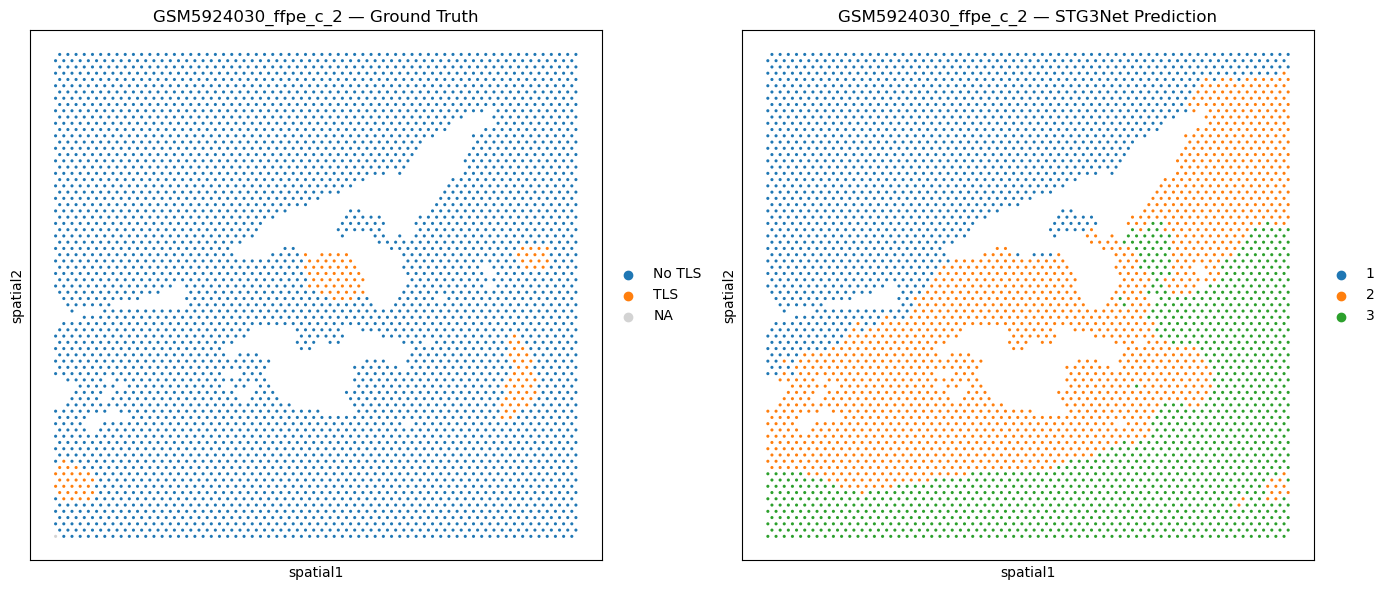

In [ ]:
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
from pathlib import Path

DATA_ROOT  = Path(r"/groups/qiwei/mocha/QuickSRT/RCC_TLS_10x/data")
OUTPUT_DIR = Path(r"/work/dal875013/projects/mocha/results/STG3Net/rcc_tls_stg3net")

SAMPLE_ID = "GSM5924030_ffpe_c_2"

predictions = pd.read_parquet(OUTPUT_DIR / "predictions.parquet")
pred_sample = predictions[predictions["sample"] == SAMPLE_ID].set_index("spot_id")

# Use the same flexible filename lookup as above.
def _find_h5ad(sample_id):
    candidates = [
        DATA_ROOT / f"SCE_{sample_id}.h5ad",
        DATA_ROOT / f"{sample_id}.h5ad",
        DATA_ROOT / f"sce_{sample_id}.h5ad",
    ]
    for p in candidates:
        if p.exists():
            return p
    matches = sorted(DATA_ROOT.glob(f"*{sample_id}*.h5ad"))
    if len(matches) == 1:
        return matches[0]
    raise FileNotFoundError(f"Could not uniquely find h5ad for {sample_id}. Matches: {matches}")

adata = sc.read_h5ad(_find_h5ad(SAMPLE_ID))

adata.obs["true_label"] = pred_sample["true_label"].reindex(adata.obs_names).values
adata.obs["pred_label"] = pred_sample["pred_label"].reindex(adata.obs_names).values

if "spatial" not in adata.obsm:
    adata.obsm["spatial"] = np.asarray(adata.obsm["S"])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sc.pl.embedding(
    adata, basis="spatial", color="true_label",
    ax=axes[0], show=False, title=f"{SAMPLE_ID} — Ground Truth", s=20,
)
sc.pl.embedding(
    adata, basis="spatial", color="pred_label",
    ax=axes[1], show=False, title=f"{SAMPLE_ID} — STG3Net Prediction", s=20,
)
axes[0].invert_yaxis()
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()


# Summary

In [ ]:
import pandas as pd
from pathlib import Path

OUTPUT_DIR = Path(r"/work/dal875013/projects/mocha/results/STG3Net/rcc_tls_stg3net")
perf_path = OUTPUT_DIR / "performance.parquet"

if not perf_path.exists():
    raise FileNotFoundError(f"Cannot find {perf_path}")

performance = pd.read_parquet(perf_path)
performance = performance.sort_values(["training_unit", "sample", "run_seed"]).reset_index(drop=True)

display_cols = [
    "training_unit", "sample", "run_seed",
    "ARI", "NMI", "ACC", "DIS",
    "num_clusters", "num_spots", "num_labeled_spots",
    "running_time_sec", "group_running_time_sec",
    "clust_method", "gpu_model",
]
display_cols = [c for c in display_cols if c in performance.columns]

print("===== STG3Net RCC_TLS Subject 22 results =====")
display(performance[display_cols])

print("\n===== Summary =====")
summary = performance[["ARI", "NMI", "ACC", "DIS", "running_time_sec"]].describe()
display(summary)

print("\n===== Mean metrics =====")
print(f"Mean ARI: {performance['ARI'].mean():.4f}")
print(f"Mean NMI: {performance['NMI'].mean():.4f}")
print(f"Mean ACC: {performance['ACC'].mean():.4f}")
print(f"Mean DIS: {performance['DIS'].mean():.4f}")

print("\n===== Group-level runtime =====")
runtime = performance[["training_unit", "run_seed", "group_running_time_sec"]].drop_duplicates()
display(runtime)
print(f"Total group-level runtime: {runtime['group_running_time_sec'].sum():.2f} sec")


===== STG3Net RCC_TLS Subject 22 results =====


,training_unit,sample,run_seed,ARI,NMI,ACC,DIS,num_clusters,num_spots,num_labeled_spots,running_time_sec,group_running_time_sec,clust_method,gpu_model
0,subject_22,GSM5924030_ffpe_c_2,0,0.006238,0.019448,0.040227,0.030934,3,4510,4509,44.33,88.66,mclust,NVIDIA A30
1,subject_22,GSM5924050_frozen_c_2,0,0.016183,0.109175,0.127725,0.068942,3,1349,1349,44.33,88.66,mclust,NVIDIA A30



===== Summary =====


,ARI,NMI,ACC,DIS,running_time_sec
count,2.000000,2.000000,2.000000,2.000000,2.00
mean,0.011210,0.064311,0.083976,0.049938,44.33
std,0.007033,0.063446,0.061871,0.026876,0.00
min,0.006238,0.019448,0.040227,0.030934,44.33
25%,0.008724,0.041879,0.062102,0.040436,44.33
50%,0.011210,0.064311,0.083976,0.049938,44.33
75%,0.013697,0.086743,0.105851,0.059440,44.33
max,0.016183,0.109175,0.127725,0.068942,44.33



===== Mean metrics =====
Mean ARI: 0.0112
Mean NMI: 0.0643
Mean ACC: 0.0840
Mean DIS: 0.0499

===== Group-level runtime =====


,training_unit,run_seed,group_running_time_sec
0,subject_22,0,88.66


Total group-level runtime: 88.66 sec
